# BE 447 Final Project

This notebook uses a reusable `DatasetClassifier` class for preprocessing, hyperparameter tuning, and evaluation on the breast cancer survival dataset.

That way we can easily test with different models and params with minimal code rewriting.

Future work before due:
analyze dataset more, like class inbalance, and how many removed data. 

## Imports

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import time


## Load Primary Dataset

In [13]:
# load in the data and turn it into a 
bcsd_df = pd.read_csv("breast_cancer_survival.csv")
print(f"Dataset shape: {bcsd_df.shape}")
print("Missing target labels:", bcsd_df["Patient_Status"].isna().sum())
print(bcsd_df.columns.tolist())
bcsd_df.head()

Dataset shape: (334, 15)
Missing target labels: 13
['Age', 'Gender', 'Protein1', 'Protein2', 'Protein3', 'Protein4', 'Tumour_Stage', 'Histology', 'ER status', 'PR status', 'HER2 status', 'Surgery_type', 'Date_of_Surgery', 'Date_of_Last_Visit', 'Patient_Status']


,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive


## Dataset Classifier Class

In [43]:
class DatasetClassifier:
    # Future expansion: I plan to add more models here once we can test that this class works.
    SUPPORTED_MODELS = {
        "svc",
        "logistic_regression",
        "random_forest",
        "knn"
        }
    SUPPORTED_NUMERIC_IMPUTERS = {"mean", "median", "mode"}
    # Future expansion: add date encoding once the model is trained with dropping. See if date encodeing improves classification
    # or adds insight to the data
    SUPPORTED_DATE_STRATEGIES = {"drop"}

    
    def __init__(
        self,
        data,
        target_column,
        model_name="svc",
        numeric_impute_strategy="median",
        categorical_impute_strategy="mode",
        date_columns=None,
        date_strategy="drop",
        scoring="f1_weighted",
        train_size=0.6,
        val_size=0.2,
        test_size=0.2,
        random_state=42,
        custom_param_grid=None,
    ):
        
        # instance member variables
        self.data = data
        self.target_column = target_column
        self.model_name = model_name
        self.numeric_impute_strategy = numeric_impute_strategy
        self.categorical_impute_strategy = categorical_impute_strategy
        self.date_columns = date_columns or []
        self.date_strategy = date_strategy
        self.scoring = scoring
        self.train_size = train_size
        self.val_size = val_size
        self.test_size = test_size
        self.random_state = random_state
        self.custom_param_grid = custom_param_grid

        # user params error section
        # We need to verify that the test training and validation sets sum up to 1 for full data
        total = train_size + val_size + test_size
        if not np.isclose(total, 1.0):
            raise ValueError("train_size + val_size + test_size must equal 1.0")
        # verify if the passed model is supported
        if model_name not in self.SUPPORTED_MODELS:
            raise ValueError(f"Unsupported model_name: {model_name}")
        # Verify if the numeric and categorical impute strategies are supported
        if numeric_impute_strategy not in self.SUPPORTED_NUMERIC_IMPUTERS:
            raise ValueError(
                "numeric_impute_strategy must be one of "
                f"{sorted(self.SUPPORTED_NUMERIC_IMPUTERS)}"
            )
        if categorical_impute_strategy != "mode":
            raise ValueError("Manual categorical imputation only supports 'mode'")
        # Verify if the date strategy is supported currently only drop. 
        if date_strategy not in self.SUPPORTED_DATE_STRATEGIES:
            raise ValueError(
                f"date_strategy must be one of {sorted(self.SUPPORTED_DATE_STRATEGIES)}"
            )
        
        # define dictionaries to hold the classification and confusion statistics
        self.report_texts_ = {}
        self.report_dicts_ = {}
        self.confusion_matrices_ = {}

    # load the dataset as a csv, then convert it into a dataframe
    def _load_dataframe(self):
        # If data passed is already a dataframe, create a copy and return the copy
        if isinstance(self.data, pd.DataFrame):
            return self.data.copy()
        # otherwise read the csv file path into a pandas dataframe
        return pd.read_csv(self.data)

    # Currently we drop the date columns with this member
    def _apply_date_strategy(self, df):
        # create a copy of the dataframe to not alter the original
        df = df.copy()
        # only try to drop date columns that actually exist in this dataframe
        valid_date_columns = [col for col in self.date_columns if col in df.columns]
        # Future expansion: I want to encode dates into numeric features instead of dropping them. to see if we can get insight on the results
        return df.drop(columns=valid_date_columns)

    # This member imputes or fills the null data points in the selected way
    # if fit is False, that means the fill values have already been calculated
    def impute(self, X, fit=False):
        # make a copy of x as not to alter the original
        X = X.copy()

        if fit:
            # create a dictionary  to store one fill value per column
            self.fill_values_ = {}
            

            for col in X.columns:
                non_null_values = []
                # collect all the values that are not missing
                for val in X[col]:
                    if pd.notna(val):
                        non_null_values.append(val)

                if len(non_null_values) == 0:
                    # fill missing values in numeric columns with 0.0 and "missing" for categorical
                    if col in self.numeric_columns_:
                        self.fill_values_[col] = 0.0
                    else:
                        self.fill_values_[col] = "Missing"
                    continue
                
                # This will implement the selected impute strategy to the numerical columns
                if col in self.numeric_columns_:
                    # this will find the average of each numeric column
                    if self.numeric_impute_strategy == "mean":
                        running_sum = 0
                        count = 0
                        for val in non_null_values:
                            running_sum += val
                            count += 1
                        self.fill_values_[col] = running_sum / count
                    # This will find the median of each numeric column
                    elif self.numeric_impute_strategy == "median":
                        # puts the values in order
                        sorted_values = sorted(non_null_values)
                        n = len(sorted_values)
                        # Divide by 2 and round to the nearest integer for the index of the middle value
                        mid = n // 2
                        # If the index is even save the average of the two middle values
                        if n % 2 == 0:
                            self.fill_values_[col] = (sorted_values[mid - 1] + sorted_values[mid]) / 2
                        # If the index is odd save the middle value for the fill value
                        else:
                            self.fill_values_[col] = sorted_values[mid]
                    # this will find the mode of each numeric column
                    else:
                        # make a dict to hold the number of each element 
                        value_counts = {}
                        # scan each non_null value in the column
                        for val in non_null_values:
                            # Add one to the current number of vals in each key.
                            value_counts[val] = value_counts.get(val, 0) + 1
                        # the fill value would be the most common value in the dict
                        self.fill_values_[col] = max(value_counts, key=value_counts.get)
                # For categorical columns find the most common value, so mode imputation
                else:
                    # make a dict to count how many times each category appears
                    value_counts = {}
                    # scan each non-missing category in the column
                    for val in non_null_values:
                        # Add one to the current count for this category
                        value_counts[val] = value_counts.get(val, 0) + 1
                    # the fill value will be the category with the highest count
                    self.fill_values_[col] = max(value_counts, key=value_counts.get)


        applicable_fill_values = {}
        for col in self.fill_values_:
            # Check if the column is in the current dataset and add the value to the dict
            if col in X.columns:
                applicable_fill_values[col] = self.fill_values_[col]
        # Fill the missing values with the fill values
        return X.fillna(applicable_fill_values)

    # this uses get_dummies to encode the columns determined in the prepare_data() member
    # When fit = true, data has not been encoded yet.
    def encode(self, X, fit=False):
        # turn categorical columns into dummy/indicator columns of 0s and 1s
        encoded = pd.get_dummies(
            X,
            columns=self.categorical_columns_,
            dtype=float,
        )

        if fit:
            # save the exact encoded column list from training data
            self.encoded_columns_ = encoded.columns.tolist()

        # make validation/test data match the training columns exactly
        # any missing dummy columns get filled with 0.0
        encoded = encoded.reindex(columns=self.encoded_columns_, fill_value=0.0)
        return encoded

    # This will scale numeric feature columns so that they are all on a comparable scale
    # this helps prevent larger magnitude features from dominating smaller ones.
    # if fit true scale the data, if fit=false, it assumes the data was already scaled
    def scale(self, X, fit=False):
        # make a copy of X so the original data is not changed
        X = X.copy()

        if fit:
            # save the numeric columns that still exist after encoding
            self.scaled_numeric_columns_ = []
            for col in self.numeric_columns_:
                if col in X.columns:
                    self.scaled_numeric_columns_.append(col)

            if self.scaled_numeric_columns_:
                # fit the scaler on the training data numeric columns only
                self.scaler_ = StandardScaler()
                self.scaler_.fit(X[self.scaled_numeric_columns_])
            else:
                # if there are no numeric columns to scale, skip scaling later
                self.scaler_ = None

        if self.scaler_ is not None and self.scaled_numeric_columns_:
            # convert numeric columns to floats before applying StandardScaler
            for col in self.scaled_numeric_columns_:
                X[col] = X[col].astype(float)

            # transform the numeric columns using the mean and standard deviation learned during fit
            scaled_values = self.scaler_.transform(X[self.scaled_numeric_columns_])
            scaled_df = pd.DataFrame(
                scaled_values,
                columns=self.scaled_numeric_columns_,
                index=X.index,
            )

            # put the scaled values back into the dataframe
            for col in self.scaled_numeric_columns_:
                X[col] = scaled_df[col]

        return X

    # this member will load the data set, prepare the data for dropping the rows where the target column is nan.
    # It will then separate the data into features and targets. 
    # Next it will use a train test split method where it splits the data into a training, validation, then test set.
    # this ensures that the test set is absolutely not touched until validating the performance. The cross validation uses
    # a separate validation set for tuning. Lastly, impute, scale and encode the data.
    def prepare_data(self):
        df = self._load_dataframe()
        # REplace any whitespace cells with nan values
        df = df.replace(r"^\s*$", np.nan, regex=True)

        
        if self.target_column not in df.columns:
            raise ValueError(f"Target column '{self.target_column}' was not found")

        # drop rows where the target is missing because the model needs a known label
        df = df.dropna(subset=[self.target_column]).reset_index(drop=True)
        # apply the current date handling strategy before separating X and y
        df = self._apply_date_strategy(df)

        # X holds the input features and y holds the target labels
        X = df.drop(columns=[self.target_column])
        y = df[self.target_column]

        # automatically determine which features are numeric
        self.numeric_columns_ = X.select_dtypes(include=np.number).columns.tolist()
        # all non-numeric features are treated as categorical
        self.categorical_columns_ = [
            col for col in X.columns if col not in self.numeric_columns_
        ]

        # save feature names and class labels for later evaluation and plotting
        self.feature_columns_ = X.columns.tolist()
        self.class_labels_ = sorted(y.unique().tolist())

        # split off the combined validation and held out-test portion from training data
        test_size = self.val_size + self.test_size
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            stratify=y,
            random_state=self.random_state,
        )

        # split that held-out portion into validation and final test sets
        relative_test_size = self.test_size / test_size
        X_val, X_test, y_val, y_test = train_test_split(
            X_test,
            y_test,
            test_size=relative_test_size,
            stratify=y_test,
            random_state=self.random_state,
        )

        # reset indexes so all split datasets have clean 0-based row numbers
        self.X_train = X_train.reset_index(drop=True)
        self.X_val = X_val.reset_index(drop=True)
        self.X_test = X_test.reset_index(drop=True)
        self.y_train = y_train.reset_index(drop=True)
        self.y_val = y_val.reset_index(drop=True)
        self.y_test = y_test.reset_index(drop=True)

        # learn imputation values from training data, then reuse them for validation and test data
        self.X_train = self.impute(self.X_train, fit=True)
        self.X_val = self.impute(self.X_val)
        self.X_test = self.impute(self.X_test)

        # learn encoded columns from training data, then force validation and test to match
        self.X_train_prepared = self.encode(self.X_train, fit=True)
        self.X_val_prepared = self.encode(self.X_val)
        self.X_test_prepared = self.encode(self.X_test)

        # learn scaling from training data, then apply the same scaling to validation and test data
        self.X_train_prepared = self.scale(self.X_train_prepared, fit=True)
        self.X_val_prepared = self.scale(self.X_val_prepared)
        self.X_test_prepared = self.scale(self.X_test_prepared)
        # mark the data as prepared so fit() does not need to prepare it again
        self.prepared_ = True
        return self

    # get the model and param grid that was passed to the class
    def _get_model_and_param_grid(self):
        # create a dictionary of dictionaries to hold the default param grids
        default_grids = {
            "svc": {
                "kernel": ["linear", "rbf"],
                "C": [0.1, 1, 10],
                "gamma": ["scale", "auto"],
            },
            "logistic_regression": {
                "C": [0.1, 1, 10],
                "solver": ["liblinear"],
            },
            "random_forest": {
                "n_estimators": [100,200],
                "max_depth": [None, 5, 10],
            },
            "knn": {
                "n_neighbors":[3, 5, 7, 9],
                "weights": ["uniform", "distance"]
            }
        }

        # A dict holding all the supported models
        models = {
        "svc": SVC(class_weight="balanced", probability=True, random_state=self.random_state),
        "logistic_regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=self.random_state),
        "random_forest": RandomForestClassifier(class_weight="balanced", random_state=self.random_state),
        "knn": KNeighborsClassifier(),
        }
        # choose the specified model from the library
        model = models[self.model_name]
        # Save the custom param grid if it has a value, if not use default
        param_grid = self.custom_param_grid or default_grids[self.model_name]
        return model, param_grid

    # this gets the specific data from either train test or validation set. 
    def _get_split_data(self, split):
        # map the split name to its prepared feature data and target labels
        split_map = {
            "train": (self.X_train_prepared, self.y_train),
            "val": (self.X_val_prepared, self.y_val),
            "test": (self.X_test_prepared, self.y_test),
        }
        # raise an error if the user asks for a split that does not exist
        if split not in split_map:
            raise ValueError("split must be one of: 'train', 'val', 'test'")
        return split_map[split]
    
    # This one will train the model without cv on the prepared training data, with all the specified settings    
    def fit_basic(self):
        if not getattr(self, "prepared_", False):
            self.prepare_data()
        
        model, _ = self._get_model_and_param_grid()
        model.fit(self.X_train_prepared, self.y_train)

        self.best_estimator_ = model
        self.val_predictions_ = model.predict(self.X_val_prepared)
        self.test_predictions_ = model.predict(self.X_test_prepared)

        return self

    # This will train the model with cross validation on the training data with all the specified settings.
    def fit(self):
        # make sure we are using prepared data
        if not getattr(self, "prepared_", False):
            self.prepare_data()

        # get the base model and parameter grid before running grid search
        model, param_grid = self._get_model_and_param_grid()
        # combine train and validation data for cross validated grid search
        X_search = pd.concat([self.X_train_prepared, self.X_val_prepared], axis=0).reset_index(drop=True)
        y_search = pd.concat([self.y_train, self.y_val], axis=0).reset_index(drop=True)
        # Use stratified k-fold during grid search so each fold keeps a similar
        # class balance while the test split stays untouched for final evaluation.
        self.cv_strategy_ = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=self.random_state,
        )

        # try each parameter combination and choose the best model based on the scoring method
        self.grid_search_ = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=self.cv_strategy_,
            scoring=self.scoring,
            n_jobs=-1,
            refit=True,
            return_train_score=True,
        )
        # train the grid search on the combined train and validation data
        self.grid_search_.fit(X_search, y_search)

        # save cv results for retrieval
        self.best_estimator_ = self.grid_search_.best_estimator_
        self.best_params_ = self.grid_search_.best_params_
        self.validation_score_ = self.grid_search_.best_score_
        # save predictions on the untouched test set for the final summary metrics
        self.test_predictions_ = self.best_estimator_.predict(self.X_test_prepared)
        return self

    # This member will predict targets based on the training weights from the best trained model
    def predict(self, split="test"):
        #self._check_is_fitted() - should probably add a helper function that will check if a model has been trained.
        # retrieve the requested prepared feature split and ignore the true labels here
        X_split, _ = self._get_split_data(split)
        return self.best_estimator_.predict(X_split)
    
    # this function will get the roc_auc_score from the best estimator
    def roc_auc(self, split="val"):
        X_split, y_true = self._get_split_data(split)

        if hasattr(self.best_estimator_, "predict_proba"):
            y_score = self.best_estimator_.predict_proba(X_split)[:, 1]
        else:
            y_score = self.best_estimator_.decision_function(X_split)

        return roc_auc_score(y_true, y_score)


    # This will run a classification report on the trained model to evaluate performance. 
    def classification_report(self, split="test"):
        #self._check_is_fitted() - should probably add a helper function that will check if a model has been trained.
        # get the true labels for the requested split
        _, y_true = self._get_split_data(split)
        # predict labels for the same split so they can be compared
        y_pred = self.predict(split=split)

        # create a printable text version of the classification report
        report_text = classification_report(
            y_true,
            y_pred,
            labels=self.class_labels_,
            zero_division=0,
        )
        # create a dictionary version so the scores can be reused later
        report_dict = classification_report(
            y_true,
            y_pred,
            labels=self.class_labels_,
            zero_division=0,
            output_dict=True,
        )

        # save both reports using the split name as the key
        self.report_texts_[split] = report_text
        self.report_dicts_[split] = report_dict
        print(report_text)
        return report_text

    # this will generate a confusion matrix by comparing the true and predicted data to provide another look at model accuracy.
    # in addition to returning the matrix to use later, it will also print the generated matrix if specified true. 
    def confusion_matrix(self, split="test", normalize=None, plot=True):
        #self._check_is_fitted() - should probably add a helper function that will check if a model has been trained.
        # get the true labels and predicted labels for the requested split
        _, y_true = self._get_split_data(split)
        y_pred = self.predict(split=split)

        # build the confusion matrix in the same class label order each time
        matrix = confusion_matrix(
            y_true,
            y_pred,
            labels=self.class_labels_,
            normalize=normalize,
        )
        # save the matrix so it can be referenced later without recalculating
        self.confusion_matrices_[split] = matrix

        if plot:
            # use decimal formatting for normalized matrices and integer formatting for raw counts
            value_format = ".2f" if normalize is not None else "d"
            # create the figure and axes for the plotted matrix
            fig, ax = plt.subplots(figsize=(6, 6))
            display = ConfusionMatrixDisplay(
                confusion_matrix=matrix,
                display_labels=self.class_labels_,
            )
            # plot the confusion matrix with readable class labels
            display.plot(ax=ax, cmap="Blues", values_format=value_format, colorbar=False)
            ax.set_title(f"{self.model_name} confusion matrix ({split})")
            plt.show()

        return matrix

    # This one will make a dataframe of a summary of this class instance. 
    def summarize_results(self):
        #self._check_is_fitted() - should probably add a helper function that will check if a model has been trained.
        # collect the main model settings and final test metrics into one row
        summary = pd.DataFrame(
            [
                {
                    "model_name": self.model_name,
                    "numeric_impute_strategy": self.numeric_impute_strategy,
                    "categorical_impute_strategy": self.categorical_impute_strategy,
                    "date_strategy": self.date_strategy,
                    "scoring": self.scoring,
                    "validation_best_score": self.validation_score_,
                    "test_accuracy": accuracy_score(self.y_test, self.test_predictions_),
                    "test_f1_weighted": f1_score(
                        self.y_test,
                        self.test_predictions_,
                        average="weighted",
                    ),
                    "best_params": str(self.best_params_),
                }
            ]
        )
        # display the summary in the notebook and return it for later use
        display(summary)
        return summary


# Helper Functions
def get_elapsed_time(start_time):
    # subtract the saved start time from the current time to get elapsed seconds
    time_elapsed = time.time() - start_time

    if time_elapsed < 60:
        # print seconds if the elapsed time is less than one minute
        print(f"Time elapsed: {time_elapsed:.2f} seconds")
    elif time_elapsed < 3600:
        # print minutes if the elapsed time is less than one hour
        print(f"Time elapsed: {time_elapsed / 60:.4f} minutes")
    else:
        # print hours for anything that takes one hour or longer
        print(f"Time elapsed: {time_elapsed / 3600:.4f} hours")

# this funciton will take the various models and train each of them on the dataset
# compare the results and save them to a dataframe
def compare_models(data, target_column, model_names, date_columns=None, basic=True):
    results = []

    for model_name in model_names:
        clf = DatasetClassifier(
            data=data,
            target_column=target_column,
            model_name=model_name,
            date_columns=date_columns,
        )

        clf.prepare_data()
        
        if basic == True:
            clf.fit_basic()
        else:
            clf.fit()

        val_pred = clf.predict(split="val")

        results.append({
            "model_name": model_name,
            "val_accuracy": accuracy_score(clf.y_val, val_pred),
            "val_f1_weighted": f1_score(clf.y_val, val_pred, average="weighted"),
            "val_roc_auc": clf.roc_auc(split="val"),
        })

    return pd.DataFrame(results).sort_values("val_roc_auc", ascending=False)


## Baseline Run

The baseline model uses SVC with median imputation for numeric columns and drops the date columns to avoid leakage from follow-up information.

Best parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


,model_name,numeric_impute_strategy,categorical_impute_strategy,date_strategy,scoring,validation_best_score,test_accuracy,test_f1_weighted,best_params
0,svc,median,mode,drop,balanced_accuracy,0.629884,0.569231,0.598763,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}"


              precision    recall  f1-score   support

       Alive       0.77      0.65      0.70        51
        Dead       0.18      0.29      0.22        14

    accuracy                           0.57        65
   macro avg       0.47      0.47      0.46        65
weighted avg       0.64      0.57      0.60        65



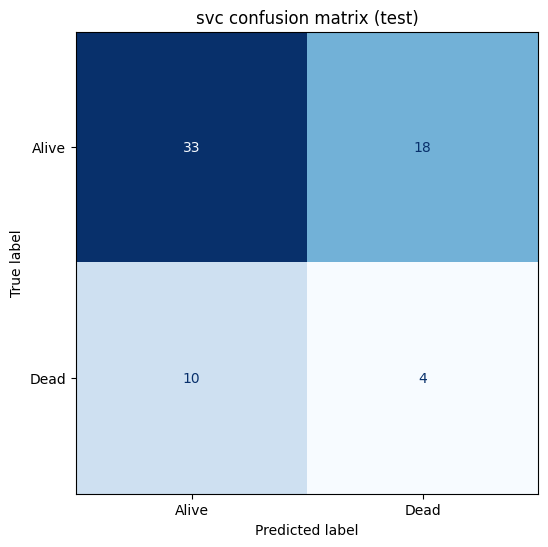

Time elapsed: 11.27 seconds


In [15]:
now = time.time()
# make an instance of the class that takes in the breast_cancer_survival dataset. with the specified parameters
# call this the baseline classifier, and we will determine what we can do to make a better classifier. 
baseline_clf = DatasetClassifier(
    data="breast_cancer_survival.csv",
    target_column="Patient_Status",
    model_name="svc",
    numeric_impute_strategy="median",
    date_columns=["Date_of_Surgery", "Date_of_Last_Visit"],
    date_strategy="drop",
    scoring="balanced_accuracy",
)

# perform the training and analyze the results
baseline_clf.fit()
print("Best parameters:", baseline_clf.best_params_)
baseline_summary = baseline_clf.summarize_results()
baseline_clf.classification_report(split="test")
baseline_clf.confusion_matrix(split="test", normalize=None, plot=True)
baseline_summary

get_elapsed_time(now)

In [54]:
now = time.time()
model_results = compare_models(
    data=bcsd_df,
    target_column="Patient_Status",
    model_names=["svc", "logistic_regression", "random_forest", "knn"],
    date_columns=["Date_of_Surgery", "Date_of_Last_Visit"],
    basic=True
)

display(model_results)
get_elapsed_time(now)

,model_name,val_accuracy,val_f1_weighted,val_roc_auc
2,random_forest,0.796875,0.706793,0.523379
1,logistic_regression,0.562500,0.602412,0.494721
3,knn,0.765625,0.729976,0.436652
0,svc,0.656250,0.685311,0.301659


Time elapsed: 1.75 seconds


              precision    recall  f1-score   support

       Alive       0.78      0.98      0.87        51
        Dead       0.00      0.00      0.00        14

    accuracy                           0.77        65
   macro avg       0.39      0.49      0.43        65
weighted avg       0.61      0.77      0.68        65



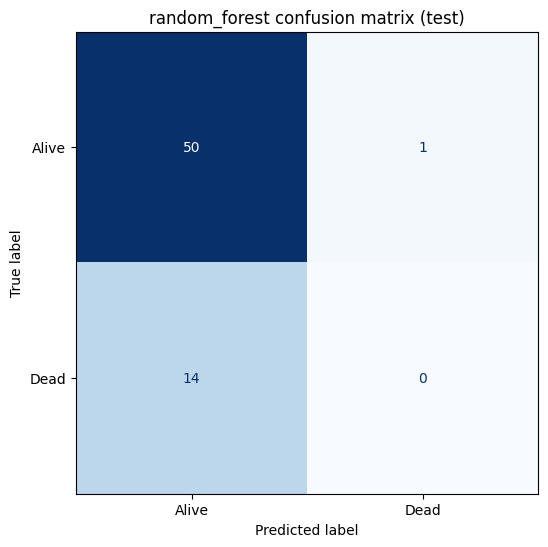

,model_name,numeric_impute_strategy,categorical_impute_strategy,date_strategy,scoring,validation_best_score,test_accuracy,test_f1_weighted,best_params
0,random_forest,median,mode,drop,f1_weighted,0.73843,0.769231,0.682274,"{'max_depth': 10, 'n_estimators': 100}"


In [55]:
best_model_name = model_results.iloc[0]["model_name"]

best_clf = DatasetClassifier(
    data=bcsd_df,
    target_column="Patient_Status",
    model_name=best_model_name,
    date_columns=["Date_of_surgery", "Date_of_Last_Visit"],
)

best_clf.fit()
best_clf.classification_report(split='test')
best_clf.confusion_matrix(split='test')
_ = best_clf.summarize_results()

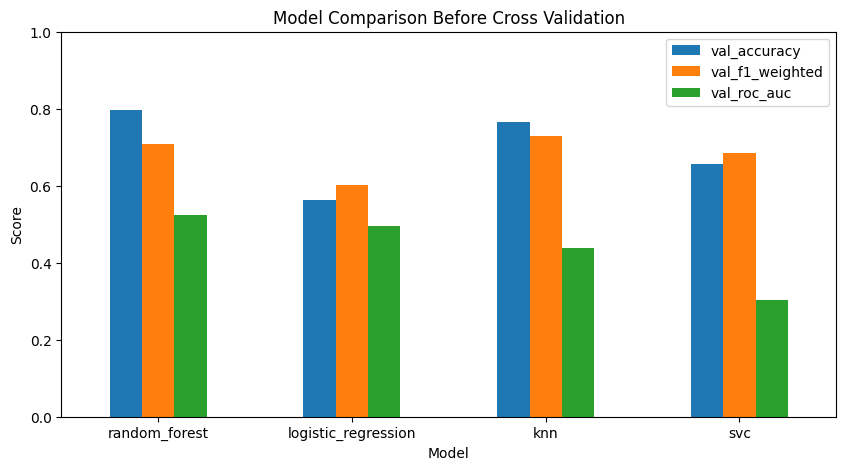

In [56]:
plot_df = model_results.sort_values("val_roc_auc", ascending=False)

plot_df.plot(
    x="model_name",
    y=["val_accuracy", "val_f1_weighted", "val_roc_auc"],
    kind="bar",
    figsize=(10, 5),
)

plt.title("Model Comparison Before Cross Validation")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()


In [50]:
now = time.time()
model_results = compare_models(
    data=bcsd_df,
    target_column="Patient_Status",
    model_names=["svc", "logistic_regression", "random_forest", "knn"],
    date_columns=["Date_of_Surgery", "Date_of_Last_Visit"],
    basic=False
)

display(model_results)
get_elapsed_time(now)

,model_name,val_accuracy,val_f1_weighted,val_roc_auc
2,random_forest,0.968750,0.968750,0.990950
0,svc,0.859375,0.870651,0.984917
3,knn,0.812500,0.777652,0.782051
1,logistic_regression,0.625000,0.660795,0.705882


Time elapsed: 1.42 seconds


              precision    recall  f1-score   support

       Alive       0.78      0.98      0.87        51
        Dead       0.00      0.00      0.00        14

    accuracy                           0.77        65
   macro avg       0.39      0.49      0.43        65
weighted avg       0.61      0.77      0.68        65



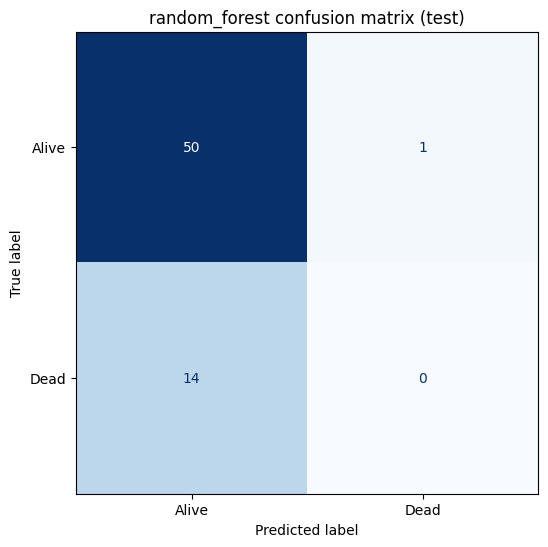

,model_name,numeric_impute_strategy,categorical_impute_strategy,date_strategy,scoring,validation_best_score,test_accuracy,test_f1_weighted,best_params
0,random_forest,median,mode,drop,f1_weighted,0.73843,0.769231,0.682274,"{'max_depth': 10, 'n_estimators': 100}"


In [51]:
best_model_name = model_results.iloc[0]["model_name"]

best_clf = DatasetClassifier(
    data=bcsd_df,
    target_column="Patient_Status",
    model_name=best_model_name,
    date_columns=["Date_of_surgery", "Date_of_Last_Visit"],
)

best_clf.fit()
best_clf.classification_report(split='test')
best_clf.confusion_matrix(split='test')
_ = best_clf.summarize_results()

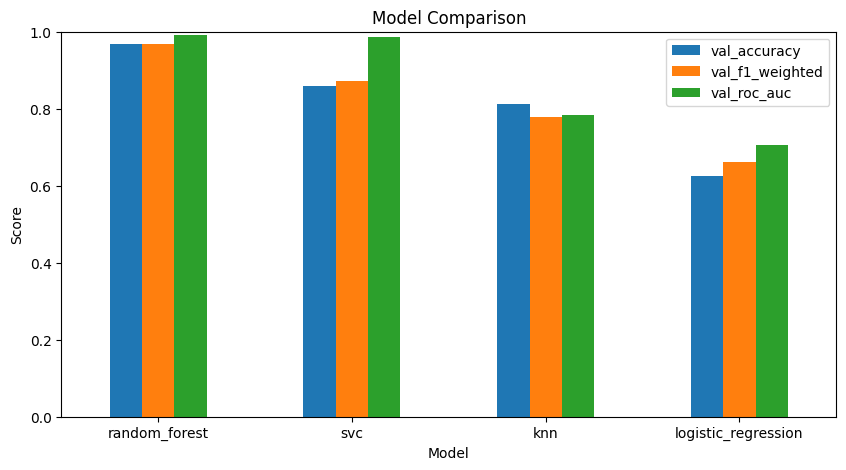

In [ ]:
plot_df = model_results.sort_values("val_roc_auc", ascending=False)

plot_df.plot(
    x="model_name",
    y=["val_accuracy", "val_f1_weighted", "val_roc_auc"],
    kind="bar",
    figsize=(10, 5),
)

plt.title("Model Comparison After Cross Validation")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()
